In [1]:
import os
import re
import pandas as pd
from pathlib import Path


def load_imdb_dataset(
    root_path,
    split=("train", "test"),
    include_unsupervised=False,
    encoding="utf-8",
    verbose=True
):
    """
    Carga el dataset IMDB desde la estructura original de carpetas.

    Parámetros
    ----------
    root_path : str o Path
        Ruta raíz del dataset (donde están /train y /test)

    split : tuple
        Qué particiones cargar ("train", "test")

    include_unsupervised : bool
        Si True, incluye /train/unsup

    encoding : str
        Encoding para lectura de archivos

    verbose : bool
        Si True, imprime progreso

    Retorna
    -------
    df : pandas.DataFrame
        Columnas:
            - review (str)
            - label (int: 0/1 o None)
            - rating (int o None)
            - split (str)
            - id (int)
    """

    root_path = Path(root_path)

    data = []

    pattern = re.compile(r"(\d+)_(\d+)\.txt")

    for sp in split:
        split_path = root_path / sp

        if not split_path.exists():
            raise ValueError(f"Split no encontrado: {split_path}")

        # Carpetas a recorrer
        categories = ["pos", "neg"]
        if include_unsupervised and sp == "train":
            categories.append("unsup")

        for category in categories:
            category_path = split_path / category

            if not category_path.exists():
                if verbose:
                    print(f"[WARN] Carpeta no encontrada: {category_path}")
                continue

            if verbose:
                print(f"Cargando {sp}/{category}...")

            for file_path in category_path.glob("*.txt"):
                try:
                    # Leer texto
                    with open(file_path, "r", encoding=encoding) as f:
                        text = f.read().strip()

                    filename = file_path.name

                    # Parsear id y rating
                    match = pattern.match(filename)

                    if match:
                        review_id = int(match.group(1))
                        rating = int(match.group(2))
                    else:
                        review_id = None
                        rating = None

                    # Determinar label
                    if category == "pos":
                        label = 1
                    elif category == "neg":
                        label = 0
                    else:  # unsup
                        label = None
                        rating = None

                    data.append({
                        "review": text,
                        "label": label,
                        "rating": rating,
                        "split": sp,
                        "id": review_id
                    })

                except Exception as e:
                    if verbose:
                        print(f"[ERROR] Archivo {file_path}: {e}")
                    continue

    df = pd.DataFrame(data)

    if verbose:
        print("\nResumen:")
        print(df.groupby(["split", "label"]).size())

    return df

In [2]:
df = load_imdb_dataset(
    root_path="",
    split=("train", "test"),
    include_unsupervised=False
)

Cargando train/pos...
Cargando train/neg...
Cargando test/pos...
Cargando test/neg...

Resumen:
split  label
test   0        12500
       1        12500
train  0        12500
       1        12500
dtype: int64


In [3]:
df.shape

(50000, 5)

In [4]:
df.head()

,review,label,rating,split,id
0,Bromwell High is a cartoon comedy. It ran at t...,1,9,train,0
1,Homelessness (or Houselessness as George Carli...,1,8,train,10000
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,10,train,10001
3,This is easily the most underrated film inn th...,1,7,train,10002
4,This is not the typical Mel Brooks film. It wa...,1,8,train,10003


In [5]:
df["label"].value_counts()

label
1    25000
0    25000
Name: count, dtype: int64

In [6]:
df["split"].value_counts()

split
train    25000
test     25000
Name: count, dtype: int64

In [ ]:
# Agregar columna de longitud de review
df["length"] = df["review"].apply(lambda x: len(x.split()))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

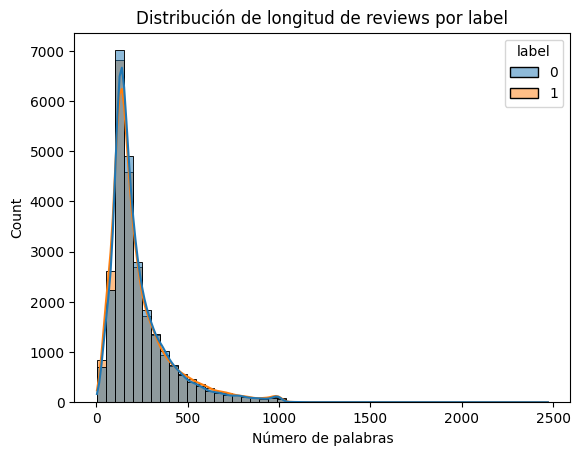

In [ ]:
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribución de longitud de reviews por label")
plt.xlabel("Número de palabras")
plt.show()

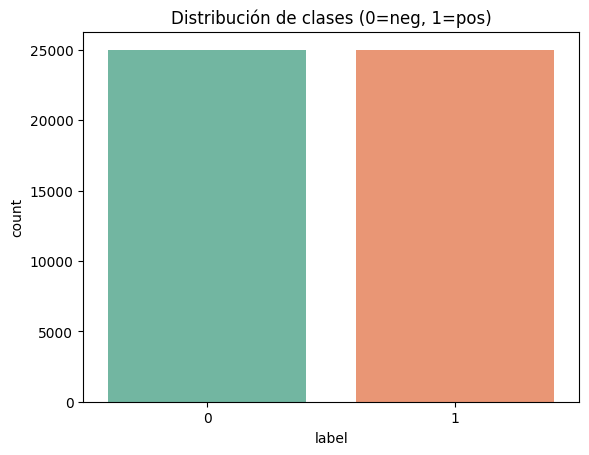

In [6]:
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Distribución de clases (0=neg, 1=pos)")
plt.show()

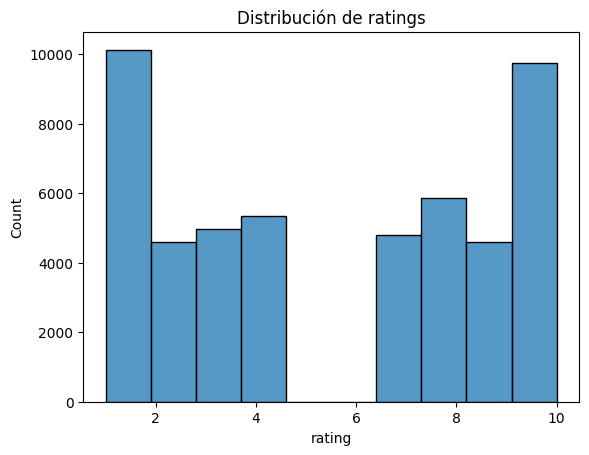

In [12]:
sns.histplot(df["rating"].dropna(), bins=10)
plt.title("Distribución de ratings")
plt.show()